# Tear Sheet Generator

**Author:** Landon Memmott
**Date:** April 2026
**Course:** Python for Finance

A program that scrapes financial data from the internet and generates a print-ready Excel tear sheet for any publicly traded company.

In [1]:
import sys
sys.path.insert(0, "../src")

from tear_sheet import generate_tear_sheet
from tear_sheet.scraper import get_company_data
from tear_sheet.financials import (
    calculate_growth_metrics,
    calculate_return_percentages,
    calculate_ratios,
    calculate_analyst_upside,
)
from tear_sheet.charts import create_price_chart, create_revenue_chart
from tear_sheet.utils import format_percentage

import matplotlib.pyplot as plt
%matplotlib inline

## 1. Data Collection

We use the `yfinance` library to fetch company information, financial statements, historical stock prices, and analyst data.

In [2]:
ticker = "CAT"
data = get_company_data(ticker)
print(f"Company: {data['info']['company_name']}")
print(f"Sector: {data['info']['sector']}")
print(f"Industry: {data['info']['industry']}")
print(f"Employees: {data['info']['employees']:,}")
print(f"\nDescription: {data['info']['description'][:200]}...")

Company: Caterpillar, Inc.
Sector: Industrials
Industry: Farm & Heavy Construction Machinery
Employees: 118,000

Description: Caterpillar Inc. provides construction and mining equipment, off-highway diesel and natural gas engines, industrial gas turbines, and diesel-electric locomotives in the United States and international...


In [3]:
# Display recent income statement
data["income_stmt"]

,2022-12-31,2023-12-31,2024-12-31,2025-12-31
Tax Effect Of Unusual Items,-1.675600e+08,8.711700e+07,1.163814e+08,6.667568e+07
Tax Rate For Calcs,2.360000e-01,2.130000e-01,1.965900e-01,2.398410e-01
Normalized EBITDA,1.212400e+10,1.529600e+10,1.544600e+10,1.402700e+10
Total Unusual Items,-7.100000e+08,4.090000e+08,5.920000e+08,2.780000e+08
Total Unusual Items Excluding Goodwill,-7.100000e+08,4.090000e+08,5.920000e+08,2.780000e+08
Net Income From Continuing Operation Net Minority Interest,6.705000e+09,1.033500e+10,1.079200e+10,8.884000e+09
Reconciled Depreciation,2.219000e+09,2.144000e+09,2.153000e+09,2.262000e+09
Reconciled Cost Of Revenue,4.191500e+10,4.379700e+10,4.148500e+10,4.611100e+10
EBITDA,1.141400e+10,1.570500e+10,1.603800e+10,1.430500e+10
EBIT,9.195000e+09,1.356100e+10,1.388500e+10,1.204300e+10


## 2. Financial Analysis

We calculate key financial metrics including revenue growth, stock returns, and financial ratios.

In [4]:
growth = calculate_growth_metrics(data["income_stmt"])
returns = calculate_return_percentages(data["history"])
ratios = calculate_ratios(data)
upside = calculate_analyst_upside(data)

print("Revenue Growth (YoY):")
for period, pct in growth["revenue_yoy"].items():
    print(f"  {period}: {format_percentage(pct)}")

print("\nStock Returns:")
for period, ret in returns.items():
    print(f"  {period}: {format_percentage(ret)}")

print("\nFinancial Ratios:")
print(f"  Current Ratio: {ratios['current_ratio']}")
print(f"  Quick Ratio: {ratios['quick_ratio']}")
print(f"  Debt-to-Equity: {ratios['debt_to_equity']}")

print(f"\nAnalyst Upside: {format_percentage(upside)}")

Revenue Growth (YoY):
  2022→2023: 12.8%
  2023→2024: -3.4%
  2024→2025: 4.3%

Stock Returns:
  1Y: 165.1%
  3Y: 283.4%
  5Y: N/A

Financial Ratios:
  Current Ratio: 1.436
  Quick Ratio: 0.871
  Debt-to-Equity: 206.67

Analyst Upside: -5.7%


## 3. Visualization

Stock price history and revenue growth charts.

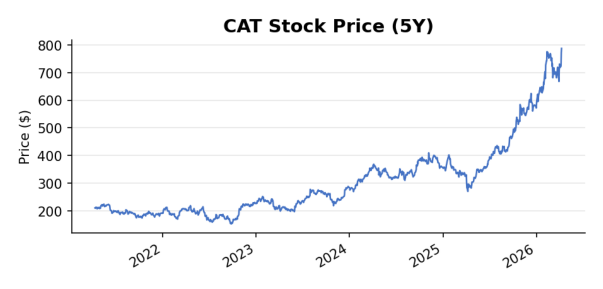

In [5]:
# Stock price chart
from PIL import Image as PILImage

buf = create_price_chart(data["history"], ticker)
img = PILImage.open(buf)
plt.figure(figsize=(8, 3.5))
plt.imshow(img)
plt.axis("off")
plt.show()

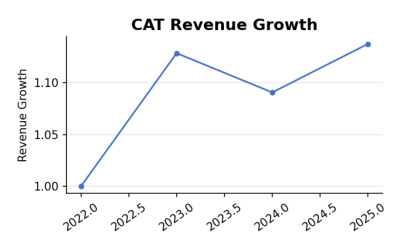

In [6]:
# Revenue growth chart
buf = create_revenue_chart(data["income_stmt"], ticker)
img = PILImage.open(buf)
plt.figure(figsize=(6, 3))
plt.imshow(img)
plt.axis("off")
plt.show()

## 4. Generate Tear Sheet

Assemble all data and charts into a formatted Excel tear sheet.

In [7]:
output_path = generate_tear_sheet(ticker)
print(f"\nTear sheet saved to: {output_path}")

Fetching data for CAT...


Calculating financial metrics...
Generating charts...
Building Excel tear sheet...
Tear sheet saved to: /Users/landonmemmott/Documents/Python_Projects/tear_sheet_generator/outputs/CAT_tear_sheet.xlsx

Tear sheet saved to: /Users/landonmemmott/Documents/Python_Projects/tear_sheet_generator/outputs/CAT_tear_sheet.xlsx


## 5. Try Another Company

Change the ticker below to generate a tear sheet for any publicly traded company.

In [8]:
another_ticker = "AAPL"  # Change this to any ticker
output_path = generate_tear_sheet(another_ticker)
print(f"Tear sheet saved to: {output_path}")

Fetching data for AAPL...


Calculating financial metrics...
Generating charts...
Building Excel tear sheet...
Tear sheet saved to: /Users/landonmemmott/Documents/Python_Projects/tear_sheet_generator/outputs/AAPL_tear_sheet.xlsx
Tear sheet saved to: /Users/landonmemmott/Documents/Python_Projects/tear_sheet_generator/outputs/AAPL_tear_sheet.xlsx
